# Lab exam Q2

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def ensure_gray(image):
    if image is None:
        raise ValueError('Expected image input')
    if image.ndim == 2:
        return image
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def ensure_bgr(image):
    if image is None:
        raise ValueError('Expected image input')
    if image.ndim == 2:
        return cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    if image.shape[2] == 4:
        return cv2.cvtColor(image, cv2.COLOR_BGRA2BGR)
    return image

def odd_ksize(value, minimum=1):
    k = int(value)
    k = max(int(minimum), k)
    if k % 2 == 0:
        k += 1
    return k

def gamma_correct(image, gamma):
    gamma = max(0.01, float(gamma))
    table = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)
    return cv2.LUT(image, table)

def show(image, title='Preview', figsize=(10, 6), cmap=None):
    plt.figure(figsize=figsize)
    if image.ndim == 2:
        plt.imshow(image, cmap=cmap or 'gray')
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

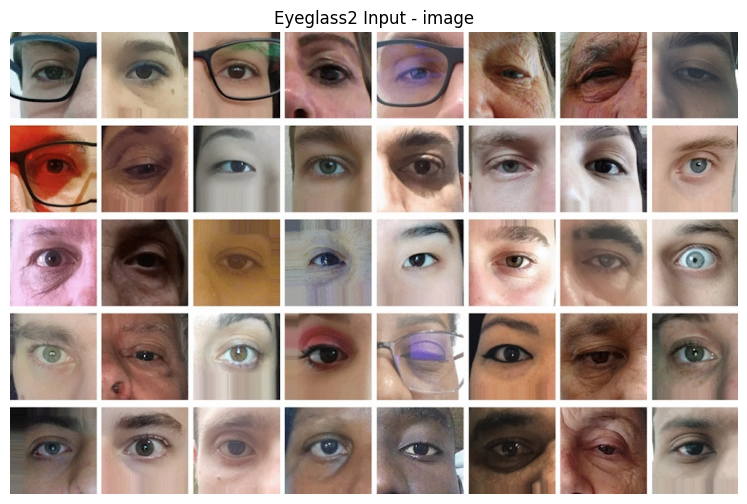

In [16]:
# Eyeglass2 Input (ImageInput)
image_path = 'eyeglass2.jpg'
eyeglass2_input = cv2.imread(str(Path(image_path).expanduser()))
if eyeglass2_input is None:
    raise FileNotFoundError(f'Unable to load image: {image_path}')

show(eyeglass2_input, title='Eyeglass2 Input - image')

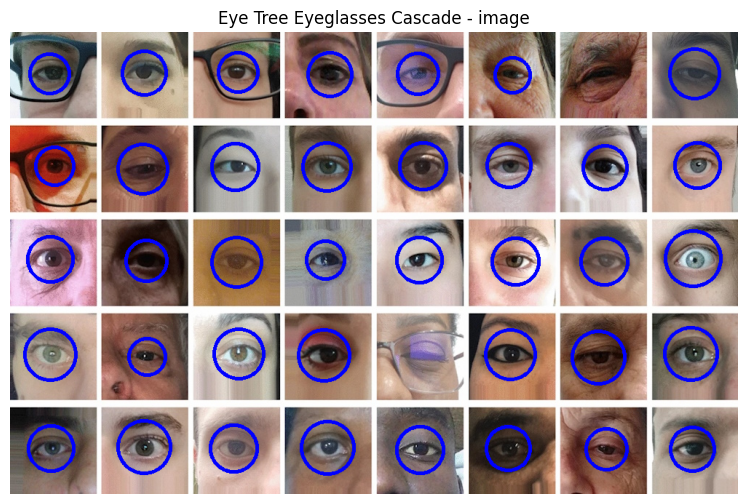

In [17]:
# Eye Tree Eyeglasses Cascade (CascadeDetectCustom)
eye_tree_eyeglasses_cascade_image = ensure_bgr(eyeglass2_input).copy()
cascade_path = 'haarcascade_eye_tree_eyeglasses.xml'
cascade_path = str(Path(cascade_path).expanduser())
_cascade = cv2.CascadeClassifier(cascade_path)
if _cascade.empty():
    raise RuntimeError(f'Failed to load cascade XML: {cascade_path}')
_gray = cv2.cvtColor(ensure_bgr(eyeglass2_input), cv2.COLOR_BGR2GRAY)
_rects = _cascade.detectMultiScale(_gray, scaleFactor=1.02, minNeighbors=8, flags=0, minSize=(15, 15), maxSize=(120, 120))
eye_tree_eyeglasses_cascade_detections = []
for (x, y, w, h) in _rects:
    x, y, w, h = int(x), int(y), int(w), int(h)
    eye_tree_eyeglasses_cascade_detections.append({'bbox': (x, y, w, h), 'label': 'eye', 'score': 1.0})
    cv2.circle(eye_tree_eyeglasses_cascade_image, (x + w // 2, y + h // 2), int(round((w + h) * 0.25)), (255, 0, 0), 3)
eye_tree_eyeglasses_cascade_meta = {'detection_count': len(eye_tree_eyeglasses_cascade_detections), 'cascade_path': cascade_path}

show(eye_tree_eyeglasses_cascade_image, title='Eye Tree Eyeglasses Cascade - image')

Contour count: 38


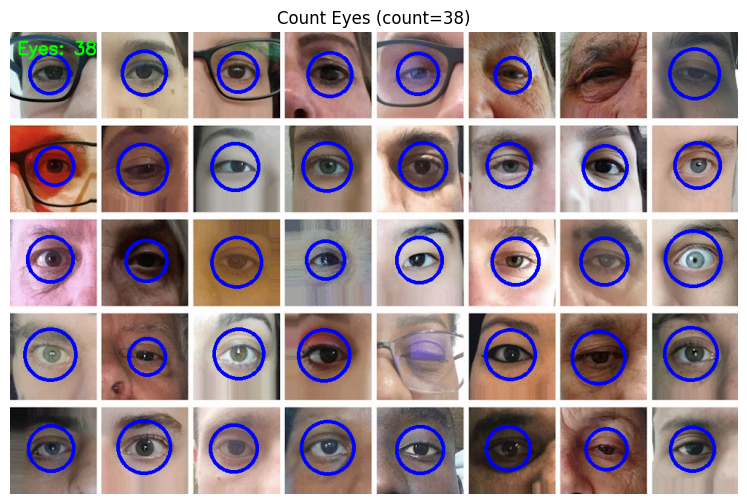

In [18]:
count_eyes_image = ensure_bgr(eye_tree_eyeglasses_cascade_image).copy()
count_eyes_detections = list(eye_tree_eyeglasses_cascade_detections or [])
label_filter = 'eye'
exact_match = True
contour_count = 0
for _det in (eye_tree_eyeglasses_cascade_detections or []):
    if isinstance(_det, dict):
        _label = str(_det.get('label', ''))
    else:
        _label = str(getattr(_det, 'label', ''))
    if not label_filter:
        contour_count += 1
    elif exact_match and _label == label_filter:
        contour_count += 1
    elif (not exact_match) and label_filter.lower() in _label.lower():
        contour_count += 1
print(f'Contour count: {contour_count}')
if True:
    cv2.putText(count_eyes_image, f"Eyes: {contour_count}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
count_eyes_meta = {
    'contour_count': contour_count,
    'label_filter': label_filter,
    'exact_match': exact_match,
    'total_detections': len(eye_tree_eyeglasses_cascade_detections or []),
}

show(count_eyes_image, title=f"Count Eyes (count={count_eyes_meta.get('contour_count', 0)})")